In [5]:
from pathlib import Path
import random, numpy as np, pandas as pd, torch, torch.nn as nn, matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

In [31]:
DATA_ROOT=Path('/media/dtsarev/SatSSD/data')
TRAIN_CSV=DATA_ROOT/'train_split.csv'
VAL_CSV=DATA_ROOT/'valid_split.csv'
EMB_IMG_DIR=Path('./cached_embeddings_img')
EMB_AUD_DIR=Path('./audio_hubert_embeds')
EMB_TXT_DIR=Path('./text_embeddings_roberta')

USE_AUDIO_STATS = True        # mean+std+min+max
PROJ_DIM        = 256         # projection size per modality
BATCH           = 128
EPOCHS          = 100
LR              = 2e-4
WEIGHT_DECAY    = 1e-4
EARLY_STOP      = 12
SCHED_PATIENCE  = 4
LAMBDA_AUX      = 0.3         # weight of auxiliary heads
LEARN_ALPHA     = True        # False → fixed α below
SEED            = 42

EMOS=["Admiration","Amusement","Determination","Empathic Pain","Excitement","Joy"]
M=len(EMOS)

# fixed weights (IMG,AUD,TXT) per emotion from previous metrics
FIX_ALPHA=np.stack([
    [0.004,0.143,0.086,0.153,0.140,0.164],   # IMG
    [0.523,0.523,0.403,0.469,0.465,0.460],   # AUD (renormed example)
    [0.473,0.334,0.511,0.378,0.395,0.376]    # TXT
])
FIX_ALPHA=FIX_ALPHA/FIX_ALPHA.sum(0,keepdims=True)  # ensure sum1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device='cuda' if torch.cuda.is_available() else 'cpu'
print('Device:',device)

Device: cuda


In [32]:
def load_npy(p):
    if not p or not p.exists(): return None
    arr=np.load(p)
    return None if arr.size==0 else arr

def agg_audio(a):
    if a is None: return None
    if a.ndim==1: return a.astype(np.float32)
    mean,std=a.mean(0),a.std(0)
    mn,mx=a.min(0),a.max(0)
    return np.concatenate([mean,std,mn,mx] if USE_AUDIO_STATS else [mean]).astype(np.float32)

class DS(Dataset):
    def __init__(self,csv,tag):
        df=pd.read_csv(csv,dtype={'Filename':str})
        df['Filename']=df['Filename'].str.zfill(5)
        self.X=[]
        self.y=[]
        for vid,*t in df[['Filename',*EMOS]].values:
            img=load_npy(EMB_IMG_DIR/f'{vid}.npy')
            aud=load_npy(next((p for p in [EMB_AUD_DIR/f'{tag}_{vid}.npy', EMB_AUD_DIR/f'{vid}.npy'] if p.exists()),None))
            aud=agg_audio(aud)
            txt=load_npy(EMB_TXT_DIR/f'{vid}.npy')
            if any(x is None for x in (img, aud, txt)):
                continue
            self.X.append(np.concatenate([img,txt,aud]).astype(np.float32))
            self.y.append(np.array(t,dtype=np.float32))
        self.X=np.stack(self.X)
        self.y=np.stack(self.y)
        print(tag,len(self))

    def __len__(self):
        return len(self.X)

    def __getitem__(self,i):
        return torch.from_numpy(self.X[i]),torch.from_numpy(self.y[i])

def pearson(p,t):
    vx,vy=p-p.mean(0),t-t.mean(0)
    return (vx*vy).sum(0)/(torch.sqrt((vx**2).sum(0)*(vy**2).sum(0))+1e-8)
class PearsonLoss(nn.Module):
    def forward(self,p,t): return 1-pearson(p,t).mean()

In [33]:
class MultiHeadFusion(nn.Module):
    def __init__(self,img_dim,txt_dim,aud_dim):
        super().__init__()
        d=PROJ_DIM
        self.img_dim,self.txt_dim,self.aud_dim=img_dim,txt_dim,aud_dim
        self.p_img=nn.Sequential(nn.LayerNorm(img_dim),nn.Linear(img_dim,d),nn.GELU())
        self.p_txt=nn.Sequential(nn.LayerNorm(txt_dim),nn.Linear(txt_dim,d),nn.GELU())
        self.p_aud=nn.Sequential(nn.LayerNorm(aud_dim),nn.Linear(aud_dim,d),nn.GELU())
        self.h_img=nn.Sequential(nn.Linear(d, M), nn.Sigmoid())
        self.h_txt=nn.Sequential(nn.Linear(d, M), nn.Sigmoid())
        self.h_aud=nn.Sequential(nn.Linear(d, M), nn.Sigmoid())
        if LEARN_ALPHA:
            self.alpha = nn.Parameter(torch.zeros(3,M))   # logits
        else:
            self.register_buffer('alpha', torch.tensor(FIX_ALPHA,dtype=torch.float32))
    def forward(self,x):
        img,txt,aud = x[:,:self.img_dim], x[:,self.img_dim:self.img_dim+self.txt_dim], x[:,self.img_dim+self.txt_dim:]
        pi,pt,pa=self.p_img(img),self.p_txt(txt),self.p_aud(aud)
        yi,yt,ya = self.h_img(pi),self.h_txt(pt),self.h_aud(pa)
        w = torch.softmax(self.alpha,dim=0) if LEARN_ALPHA else self.alpha
        y = w[0]*yi + w[1]*ya + w[2]*yt
        return y,(yi,ya,yt),w.detach()

In [34]:
train_ds, val_ds = DS(TRAIN_CSV, 'train'), DS(VAL_CSV, 'val')
train_dl = DataLoader(train_ds, BATCH, shuffle=True, drop_last=True)
val_dl   = DataLoader(val_ds,   BATCH, shuffle=False)

feat, _ = next(iter(train_dl))
TXT_DIM = 768
AUD_DIM = 768*4 if USE_AUDIO_STATS else 768
IMG_DIM = feat.shape[1] - TXT_DIM - AUD_DIM

model = MultiHeadFusion(IMG_DIM, TXT_DIM, AUD_DIM).to(device)
loss_fn = PearsonLoss()
opt     = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched   = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=SCHED_PATIENCE, min_lr=1e-6)

train 7953
val 4565


In [36]:
hist = {'loss_tr':[], 'loss_val':[], 'r_tr':[], 'r_val':[], 'lr':[]}
best_r = -1e9; wait = 0
for epoch in range(1, EPOCHS+1):
    for phase, dl in [('train', train_dl), ('val', val_dl)]:
        model.train() if phase == 'train' else model.eval()
        tot_loss = tot_r = n = 0
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            if phase == 'train':
                opt.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                y, (yi, ya, yt), _ = model(xb)
                loss_main = loss_fn(y, yb)
                loss_aux  = (loss_fn(yi,yb)+loss_fn(ya,yb)+loss_fn(yt,yb))/3
                loss = loss_main + LAMBDA_AUX*loss_aux
                if phase == 'train':
                    loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            r = pearson(y, yb).mean().item()
            bs = xb.size(0)
            tot_loss += loss.item()*bs; tot_r += r*bs; n += bs
        epoch_loss = tot_loss / n; epoch_r = tot_r / n
        key = 'tr' if phase=='train' else 'val'
        hist[f'loss_{key}'].append(epoch_loss)
        hist[f'r_{key}'].append(epoch_r)
        if phase == 'val':
            sched.step(epoch_loss)
    current_lr = opt.param_groups[0]['lr']
    hist['lr'].append(current_lr)
    print(f"Ep{epoch:02d} | L_tr {hist['loss_tr'][-1]:.3f} L_val {hist['loss_val'][-1]:.3f} | R_tr {hist['r_tr'][-1]:.3f} R_val {hist['r_val'][-1]:.3f} | lr {current_lr}")

Ep01 | L_tr 1.064 L_val 1.006 | R_tr 0.193 R_val 0.241 | lr 0.0002
Ep02 | L_tr 0.791 L_val 0.914 | R_tr 0.416 R_val 0.317 | lr 0.0002
Ep03 | L_tr 0.700 L_val 0.906 | R_tr 0.491 R_val 0.323 | lr 0.0002
Ep04 | L_tr 0.640 L_val 0.889 | R_tr 0.541 R_val 0.336 | lr 0.0002
Ep05 | L_tr 0.605 L_val 0.896 | R_tr 0.570 R_val 0.331 | lr 0.0002
Ep06 | L_tr 0.574 L_val 0.901 | R_tr 0.595 R_val 0.326 | lr 0.0002
Ep07 | L_tr 0.549 L_val 0.901 | R_tr 0.617 R_val 0.326 | lr 0.0002
Ep08 | L_tr 0.521 L_val 0.907 | R_tr 0.641 R_val 0.321 | lr 0.0002
Ep09 | L_tr 0.500 L_val 0.921 | R_tr 0.659 R_val 0.309 | lr 0.0001
Ep10 | L_tr 0.457 L_val 0.915 | R_tr 0.694 R_val 0.316 | lr 0.0001
Ep11 | L_tr 0.444 L_val 0.917 | R_tr 0.705 R_val 0.313 | lr 0.0001
Ep12 | L_tr 0.428 L_val 0.926 | R_tr 0.719 R_val 0.306 | lr 0.0001
Ep13 | L_tr 0.421 L_val 0.928 | R_tr 0.725 R_val 0.303 | lr 0.0001
Ep14 | L_tr 0.414 L_val 0.932 | R_tr 0.731 R_val 0.301 | lr 5e-05
Ep15 | L_tr 0.387 L_val 0.933 | R_tr 0.753 R_val 0.301 | lr 5e-

In [37]:
model.eval()
P,T=[],[]

with torch.no_grad():
    for xb,yb in val_dl:
        p=model(xb.to(device))[0].cpu()
        P.append(p)
        T.append(yb)

P,T=torch.cat(P),torch.cat(T)
print("\nPer‑emotion R (val):")
for i,e in enumerate(EMOS):
    print(f"{e:<15} : {pearson(P[:,i],T[:,i]).item():+.3f}")
print('Mean R:', pearson(P,T).mean().item())


Per‑emotion R (val):
Admiration      : +0.343
Amusement       : +0.265
Determination   : +0.241
Empathic Pain   : +0.339
Excitement      : +0.271
Joy             : +0.238
Mean R: 0.28272905945777893


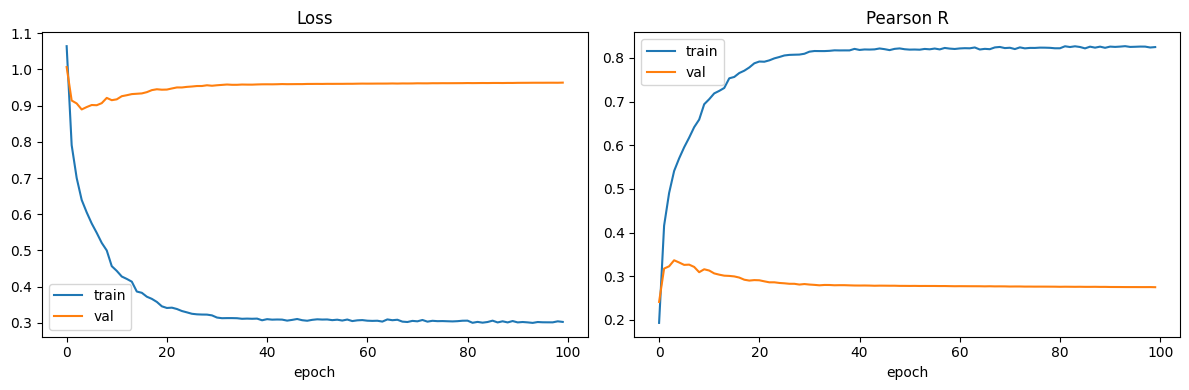

Text(0.5, 0, 'epoch')

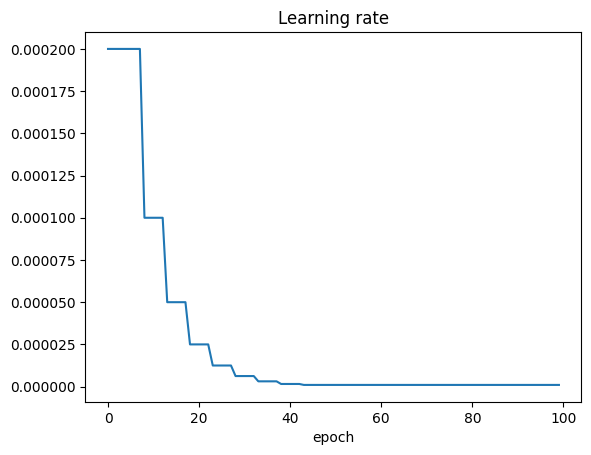

In [38]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist['loss_tr'], label='train'); plt.plot(hist['loss_val'], label='val')
plt.title('Loss'); plt.xlabel('epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(hist['r_tr'], label='train'); plt.plot(hist['r_val'], label='val')
plt.title('Pearson R'); plt.xlabel('epoch'); plt.legend()
plt.tight_layout(); plt.show()

plt.figure(); plt.plot(hist['lr']); plt.title('Learning rate'); plt.xlabel('epoch')